# Synthetic Minority Oversampling — CopulaGAN + CTGAN


**Strategy:** GANs are trained on the *full* minority class (all splits) to maximise distributional coverage (~75 rows vs ~50). Synthetic samples are injected **exclusively into the training split** — validation and test remain 100% real.

**Post-processing pipeline:**
1. Train CopulaGAN + CTGAN on raw features + BC (derived) so the model learns the ADD/SUB/CA joint structure.
2. Quantile-match each feature marginal on the full candidate pool.
3. KNN filter — retain the top 90th-percentile candidates closest to the real minority set.
4. Uniform sample to the required count (avoids centroid bias).
5. Hard assert: selected set must pass all distribution checks before proceeding.
6. Recompute all derived features deterministically from raw features.


## 1. Imports & Configuration

In [21]:
import pandas as pd
import numpy as np
import random, os, warnings
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import json
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sdv.single_table import CopulaGANSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from pathlib import Path

warnings.filterwarnings('ignore')

# Set Seed for reproducability
SEED = 42

EPSILON      = 1e-9
RAW_FEATURES = ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
GAN_FEATURES = RAW_FEATURES + ['BC']   # BC included so GAN learns ADD/SUB/CA joint

ROOT_DIR = Path('..')
DATASETS_DIR = ROOT_DIR / 'datasets'
OUTPUTS_DIR = ROOT_DIR / 'outputs'

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'
REAL_COLOR = '#54A24B'
SYNTHETIC_COLOR = '#E45756'

# Load empirical missing rates from file (per label, per feature).
MISSING_RATES = {}
try:
    with open(OUTPUTS_DIR / 'missing_rates.json', encoding='utf-8') as file:
        loaded_rates = json.load(file)

    # Normalize label keys to strings so downstream lookup is consistent.
    MISSING_RATES = {str(k): v for k, v in loaded_rates.items()}

    # Validate expected schema: labels -> RAW_FEATURES -> numeric rates in [0, 1].
    for lbl in ['0', '1']:
        if lbl not in MISSING_RATES:
            raise ValueError(f"Missing label key '{lbl}' in missing_rates.json")
        for f in RAW_FEATURES:
            if f not in MISSING_RATES[lbl]:
                raise ValueError(f"Missing feature '{f}' under label '{lbl}' in missing_rates.json")
            MISSING_RATES[lbl][f] = float(np.clip(MISSING_RATES[lbl][f], 0.0, 1.0))

    print(f"{MISSING_RATES=}")
except FileNotFoundError:
    print(f"File not found: {OUTPUTS_DIR / 'missing_rates.json'}")
except json.JSONDecodeError:
    print(f"Invalid JSON format: {OUTPUTS_DIR / 'missing_rates.json'}")
except ValueError as err:
    print(f"Invalid missing-rate schema: {err}")

# Real Train Data only (both labels 0 and 1)
print('Configuration loaded.')
print(f'  RAW_FEATURES : {RAW_FEATURES}')
print(f'  GAN_FEATURES : {GAN_FEATURES}')


MISSING_RATES={'0': {'NC': 0.0, 'DM': 0.005, 'NS': 0.014, 'ADD': 0.018, 'SUB': 0.032, 'CA': 0.068}, '1': {'NC': 0.014, 'DM': 0.014, 'NS': 0.036, 'ADD': 0.029, 'SUB': 0.029, 'CA': 0.087}}
Configuration loaded.
  RAW_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
  GAN_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'BC']


## 2. Helper Functions

In [22]:
def set_seed(seed):
    """Global seed for full reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def compute_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features from raw features deterministically."""
    df = df.copy()
    df['NP'] = (df['NC'] + df['DM']) / 2                           # Eq. 3.3
    df['SN'] = df['NC'] - df['DM']                                  # Eq. 3.4
    df['AF'] = (df['NS'] + df['ADD'] + df['SUB'] + df['CA']) / 4   # Eq. 3.5
    df['BC'] = (df['ADD'] + df['SUB']) / 2 - df['CA']              # Eq. 3.6
    df['AS'] = df['ADD'] - df['SUB']                                # Eq. 3.7
    df['PF'] = df['AF'] / (df['NP'] + EPSILON)                     # Eq. 3.8
    return df


def inject_synthetic_missing(df: pd.DataFrame, missing_rates: dict,
                               features: list, df_min_ref: pd.DataFrame,
                               label_val: int = 1,
                               random_state: int = SEED) -> pd.DataFrame:
    """
    Simulate missing data in SYNTHETIC rows:
      1. Mark rows as missing per empirical rates.
      2. Impute with real minority-class median.
      3. Set <feature>_incomplete = 1.
    """
    print("\nGenerating synthetic incomplete flags...")
    rng = np.random.default_rng(random_state)
    df = df.copy()

    # Support both integer and string label keys (e.g., 1 and '1').
    rates = missing_rates.get(str(label_val), missing_rates.get(label_val, {}))

    feature_medians = {f: df_min_ref[f].median() for f in features}
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df[col] = 0
        rate = float(np.clip(rates.get(f, 0.0), 0.0, 1.0))
        if rate <= 0.0:
            continue
        mask = rng.binomial(1, rate, size=len(df)).astype(bool)
        if mask.sum() == 0:
            continue
        df.loc[mask, f] = feature_medians[f]
        df.loc[mask, col] = 1
    df['any_incomplete'] = (df[inc_cols].sum(axis=1) > 0).astype(int)
    print("Finished generating synthetic flags.")
    return df


print('Helper functions defined.')


Helper functions defined.


In [14]:
def distribution_check(
    df_syn_min: pd.DataFrame,
    df_train_min_full: pd.DataFrame,
    features: list,
    T_mu: float = 0.10,
    T_sigma: float = 0.17,
    T_med: float = 0.12,
    T_skew: float = 0.75,
    T_kurt: float = 1.5,
    JSD_THRESHOLD: float = 0.10,
) -> tuple:
    """
    Statistical similarity check between real and synthetic minority-class data.
    Returns (all_pass: bool, results: pd.DataFrame).

    Checks per feature (Eq. 3.14 – 3.25):
      KS test       — H0: same distribution; reject at α=0.05
      JSD           — Jensen-Shannon divergence over 20 bins < JSD_THRESHOLD
      Δμ, Δσ, Δmed  — normalised mean / std / median differences
      Δskew, Δkurt  — absolute skewness / excess-kurtosis differences
    """
    all_pass_global = True
    results = []

    hdr = f"{'Feature':<10} {'KS (p>0.05)':>22} {'JSD':>18} {'Δμ':>18} {'Δσ':>18} {'Δmed':>18} {'Δskew':>18} {'Δkurt':>18} {'ALL':>6}"
    print(hdr)
    print('-' * len(hdr))

    for f in features:
        real_f = df_train_min_full[f].values
        syn_f  = df_syn_min[f].values

        # KS test (Eq. 3.14)
        ks_stat, p_value = stats.ks_2samp(real_f, syn_f)
        ks_pass = p_value > 0.05
        ks_str  = f"D={ks_stat:.4f} p={p_value:.4f} {'✓' if ks_pass else '✗'}"

        # Summary statistics
        mean_r, mean_s = np.mean(real_f),              np.mean(syn_f)
        std_r,  std_s  = np.std(real_f, ddof=1),       np.std(syn_f, ddof=1)
        med_r,  med_s  = np.median(real_f),            np.median(syn_f)
        skew_r, skew_s = stats.skew(real_f, bias=True), stats.skew(syn_f, bias=True)
        kurt_r, kurt_s = stats.kurtosis(real_f, bias=True), stats.kurtosis(syn_f, bias=True)

        # Normalised differences (Eq. 3.20 – 3.24)
        delta_mu   = abs(mean_s - mean_r) / (abs(mean_r) + EPSILON)
        delta_std  = abs(std_s  - std_r)  / (std_r       + EPSILON)
        delta_med  = abs(med_s  - med_r)  / (abs(med_r)  + EPSILON)
        delta_skew = abs(skew_s - skew_r)
        delta_kurt = abs(kurt_s - kurt_r)

        mu_pass   = delta_mu   < T_mu
        std_pass  = delta_std  < T_sigma
        med_pass  = delta_med  < T_med
        skew_pass = delta_skew < T_skew
        kurt_pass = delta_kurt < T_kurt

        # JSD (Eq. 3.25)
        bins         = np.histogram_bin_edges(np.concatenate([real_f, syn_f]), bins=20)
        p_real, _    = np.histogram(real_f, bins=bins, density=True)
        p_syn,  _    = np.histogram(syn_f,  bins=bins, density=True)
        jsd_val      = jensenshannon(p_real + EPSILON, p_syn + EPSILON) ** 2
        jsd_pass     = jsd_val < JSD_THRESHOLD

        stats_pass   = mu_pass and std_pass and med_pass and skew_pass and kurt_pass
        feature_pass = ks_pass and jsd_pass and stats_pass
        all_pass_global = all_pass_global and feature_pass

        jsd_s = f"{jsd_val:.4f}<{JSD_THRESHOLD} {'✓' if jsd_pass else '✗'}"
        mu_s  = f"{delta_mu:.4f}<{T_mu} {'✓' if mu_pass else '✗'}"
        sig_s = f"{delta_std:.4f}<{T_sigma} {'✓' if std_pass else '✗'}"
        med_s = f"{delta_med:.4f}<{T_med} {'✓' if med_pass else '✗'}"
        skw_s = f"{delta_skew:.4f}<{T_skew} {'✓' if skew_pass else '✗'}"
        krt_s = f"{delta_kurt:.4f}<{T_kurt} {'✓' if kurt_pass else '✗'}"
        print(f"{f:<10} {ks_str:>22} {jsd_s:>18} {mu_s:>18} {sig_s:>18} {med_s:>18} {skw_s:>18} {krt_s:>18} {'✓' if feature_pass else '✗':>6}")

        results.append(dict(
            feature=f, KS_stat=ks_stat, KS_p=p_value,
            JSD=jsd_val, delta_mu=delta_mu, delta_std=delta_std,
            delta_med=delta_med, delta_skew=delta_skew, delta_kurt=delta_kurt,
            ALL_pass=feature_pass,
        ))

    print('-' * len(hdr))
    print('Overall:', 'ALL FEATURES PASS ✓' if all_pass_global else 'Some features FAILED ❌')
    return all_pass_global, pd.DataFrame(results)


print('distribution_check() defined.')


distribution_check() defined.


## 3. Data Loading & Splitting

In [15]:
df     = pd.read_csv(DATASETS_DIR / 'cleaned_dataset.csv')
df_raw = df[RAW_FEATURES + ['Label']].copy()

# Keep the source split with its existing incomplete flags intact.
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df['Label'], random_state=SEED)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['Label'], random_state=SEED)

df_train_raw = df_train[RAW_FEATURES + ['Label']].copy()
df_train_maj = df_train_raw[df_train_raw['Label'] == 0]
df_train_min = df_train_raw[df_train_raw['Label'] == 1]
n_synthetic_needed = len(df_train_maj) - len(df_train_min)

print('Data split (70 / 15 / 15):')
print(f'  Train      : {len(df_train):>4}  (maj={len(df_train_maj)}, min={len(df_train_min)})')
print(f'  Validation : {len(df_val):>4}')
print(f'  Test       : {len(df_test):>4}')
print(f'  Synthetic samples needed to balance train: {n_synthetic_needed}')

# Full minority set — used ONLY to train the GANs
df_min_all = df_raw[df_raw['Label'] == 1][RAW_FEATURES].copy()
df_min_all['BC'] = (df_min_all['ADD'] + df_min_all['SUB']) / 2 - df_min_all['CA']
df_min_ref = df_min_all.copy()   # reference used for all checks

print(f'\nMinority rows available for GAN training: {len(df_min_all)}')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_all)


Data split (70 / 15 / 15):
  Train      :  250  (maj=154, min=96)
  Validation :   54
  Test       :   54
  Synthetic samples needed to balance train: 58

Minority rows available for GAN training: 138


## 4. GAN Training & Candidate Selection

Both GANs are trained on `GAN_FEATURES` (raw + BC) so the model learns the joint ADD/SUB/CA structure. An auto-retry loop walks through `GAN_SEARCH_GRID` and stops at the first configuration that passes all distribution checks.


In [16]:
# Hyperparameter search grid.
# Each entry: (MULTIPLIER, epochs, batch_size, gen_lr, disc_lr)
GAN_SEARCH_GRID = [
    ( 7, 2000, 500, 2e-4, 2e-4),   # baseline
    (10, 2000, 500, 2e-4, 2e-4),   # bigger pool
    (10, 3000, 500, 2e-4, 2e-4),   # more epochs
    (10, 3000, 100, 2e-4, 2e-4),   # smaller batch
    (15, 3000, 100, 1e-4, 1e-4),   # lower LR
    (15, 5000, 100, 1e-4, 1e-4),   # high epochs
    (20, 5000, 100, 1e-4, 1e-4),   # max effort
]

# Default thresholds for the statistical measurements
DIST_THRESHOLDS = dict(
    T_mu=0.10, T_sigma=0.15, T_med=0.1,
    T_skew=0.75, T_kurt=1.5, JSD_THRESHOLD=0.10
)

# Fit scaler once on real minority data
scaler_global = StandardScaler().fit(df_min_all[GAN_FEATURES])


def run_gan_pipeline(config, seed=SEED, thresholds=None):
    """Train GANs, post-process, filter, and check distribution for one config."""
    if thresholds is None:
        thresholds = DIST_THRESHOLDS
    set_seed(seed)
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    n_generate = n_synthetic_needed * MULTIPLIER
    n_copula   = n_generate // 2
    n_ctgan    = n_generate - n_copula

    # Scale training data
    df_scaled = df_min_all.copy()
    df_scaled[GAN_FEATURES] = scaler_global.transform(df_scaled[GAN_FEATURES])

    common_kwargs = dict(
        metadata          = metadata,
        enforce_rounding  = False,
        embedding_dim     = 32,
        generator_dim     = (128, 128),
        discriminator_dim = (128, 128),
        epochs            = epochs,
        batch_size        = min(batch_size, 64),
        generator_lr      = gen_lr / 2,
        discriminator_lr  = disc_lr / 2,
        discriminator_steps = 2,
        pac               = 2,
        verbose           = True,
        enable_gpu        = False,
    )

    copula_synth = CopulaGANSynthesizer(**common_kwargs)
    copula_synth.fit(df_scaled)
    df_copula = copula_synth.sample(num_rows=n_copula)
    df_copula['source'] = 'copula'

    ctgan_synth = CTGANSynthesizer(**common_kwargs)
    ctgan_synth.fit(df_scaled)
    df_ctgan = ctgan_synth.sample(num_rows=n_ctgan)
    df_ctgan['source'] = 'ctgan'

    df_syn_raw = pd.concat([df_copula, df_ctgan], ignore_index=True)
    # ── Inverse scale back ──
    df_syn_raw[GAN_FEATURES] = scaler_global.inverse_transform(df_syn_raw[GAN_FEATURES])

    # ── Clip to observed real range (no redistribution) ──
    df_syn_pp = df_syn_raw[GAN_FEATURES + ['source']].copy()
    for f in GAN_FEATURES:
        lo = df_min_all[f].min()
        hi = df_min_all[f].max()
        df_syn_pp[f] = df_syn_pp[f].clip(lo, hi)

    # ── Round and cast integer features back to int64 ──
    # Must happen before distribution check so checks run on the same
    # dtype that will actually be saved — KS/JSD on floats vs integers
    # of the same values can produce different results.
    INT_FEATURES = ['NS', 'ADD', 'SUB', 'CA']
    for f in INT_FEATURES:
        if f in df_syn_pp.columns:
            df_syn_pp[f] = df_syn_pp[f].round().astype('int64')

    # KNN filter — keep top-90th-percentile candidates
    sc      = StandardScaler().fit(df_min_ref[GAN_FEATURES])
    real_sc = sc.transform(df_min_ref[GAN_FEATURES])
    syn_sc  = sc.transform(df_syn_pp[GAN_FEATURES])
    dists, _ = NearestNeighbors(n_neighbors=5).fit(real_sc).kneighbors(syn_sc)
    df_syn_pp['_knn'] = dists.mean(axis=1)
    thr = np.percentile(df_syn_pp['_knn'], 90)
    df_eligible = df_syn_pp[df_syn_pp['_knn'] <= thr].copy()

    df_selected = (
        df_eligible
        .sample(n=min(n_synthetic_needed, len(df_eligible)), random_state=seed)
        .drop(columns=['_knn', 'source', 'BC'])
        .reset_index(drop=True)
    )

    passed, df_stats = distribution_check(
        df_syn_min        = df_selected,
        df_train_min_full = df_min_ref,
        features          = RAW_FEATURES,
        **thresholds,
    )
    return passed, df_selected, df_syn_pp, df_stats

print('GAN pipeline function defined.')


GAN pipeline function defined.


In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Hyperparameter Search — auto-selects the best passing config
#
# For every config that passes, a similarity score is computed as the
# sum of all normalised metric values (lower = closer to real data).
# The passing config with the lowest score is kept as df_selected.
# ─────────────────────────────────────────────────────────────────────────
search_results  = []
best_score      = np.inf
df_selected     = None
df_syn_pp       = None
df_dist_results = None
best_config     = None

for attempt, config in enumerate(GAN_SEARCH_GRID, 1):
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config
    print(f'\n[{attempt}/{len(GAN_SEARCH_GRID)}] MULTIPLIER={MULTIPLIER}, epochs={epochs}, '
          f'batch={batch_size}, lr=({gen_lr:.0e},{disc_lr:.0e})')
    print('-' * 70)

    passed, df_sel_tmp, df_pp_tmp, df_stats_tmp = run_gan_pipeline(
        config, seed=SEED, thresholds=DIST_THRESHOLDS
    )

    if passed:
        # Score = sum of all normalised metric values (lower is better)
        score = df_stats_tmp[
            ['delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt', 'JSD']
        ].sum().sum()

        search_results.append((config, True, score))
        print(f'\n  → ✓ PASS  (score={score:.4f})')

        if score < best_score:
            best_score      = score
            df_selected     = df_sel_tmp
            df_syn_pp       = df_pp_tmp
            df_dist_results = df_stats_tmp
            best_config     = config
    else:
        search_results.append((config, False, np.inf))
        print(f'\n  → ✗ FAIL')

print('\n' + '=' * 70)
print('Search complete. Summary:')
print('=' * 70)
for cfg, ok, sc in search_results:
    mult, ep, bs, glr, dlr = cfg
    score_str = f'score={sc:.4f}' if ok else '       —      '
    marker    = ' ← best' if cfg == best_config else ''
    print(f'  MULT={mult:>2} ep={ep:>4} bs={bs:>3} lr=({glr:.0e},{dlr:.0e})  →  '
          f'{"✓ PASS" if ok else "✗ FAIL"}  {score_str}{marker}')

assert df_selected is not None, (
    'All configs failed — do not patch the data. Extend the grid or investigate GAN quality.'
)

df_selected['Label'] = 1
print(f'\n✓ Best config  : {best_config}')
print(f'  Best score   : {best_score:.4f}')
print(f'  Selected rows: {df_selected.shape[0]}')


[1/7] MULTIPLIER=7, epochs=2000, batch=500, lr=(2e-04,2e-04)
----------------------------------------------------------------------


Gen. (-00.52) | Discrim. (-00.05): 100%|██████████| 2000/2000 [00:52<00:00, 37.83it/s]
Gen. (-00.30) | Discrim. (-00.16): 100%|██████████| 2000/2000 [00:50<00:00, 39.34it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1122 p=0.6328 ✓       0.0506<0.1 ✓       0.0295<0.1 ✓      0.0062<0.15 ✓       0.0462<0.1 ✓      0.2949<0.75 ✓       0.3013<1.5 ✓      ✓
DM            D=0.0827 p=0.9153 ✓       0.0466<0.1 ✓       0.0259<0.1 ✓      0.0829<0.15 ✓       0.0034<0.1 ✓      0.2182<0.75 ✓       0.6284<1.5 ✓      ✓
NS            D=0.0767 p=0.9506 ✓       0.0687<0.1 ✓       0.0320<0.1 ✓      0.0056<0.15 ✓       0.0455<0.1 ✓      0.2398<0.75 ✓       0.2541<1.5 ✓      ✓
ADD           D=0.0960 p=0.8032 ✓       0.0440<0.1 ✓       0.0622<0.1 ✓      0.0502<0.15 ✓       0.0690<0.1 ✓      0.2257<0.75 ✓       0.0843<1.5 ✓      ✓
SUB           D=0.0950 p=0.8131 ✓       0.0791<0.1 ✓       0.0197<0.1 

Gen. (-00.52) | Discrim. (-00.05): 100%|██████████| 2000/2000 [00:51<00:00, 38.89it/s]
Gen. (-00.30) | Discrim. (-00.16): 100%|██████████| 2000/2000 [00:54<00:00, 37.02it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1204 p=0.5445 ✓       0.0792<0.1 ✓       0.0123<0.1 ✓      0.0366<0.15 ✓       0.0822<0.1 ✓      0.0402<0.75 ✓       0.5437<1.5 ✓      ✓
DM            D=0.1689 p=0.1698 ✓       0.0827<0.1 ✓       0.0765<0.1 ✓      0.0464<0.15 ✓       0.0522<0.1 ✓      0.1589<0.75 ✓       0.3675<1.5 ✓      ✓
NS            D=0.1689 p=0.1698 ✓       0.0662<0.1 ✓       0.1557<0.1 ✗      0.0248<0.15 ✓       0.1818<0.1 ✗      0.2166<0.75 ✓       0.2821<1.5 ✓      ✗
ADD           D=0.1004 p=0.7580 ✓       0.0480<0.1 ✓       0.0576<0.1 ✓      0.0153<0.15 ✓       0.0862<0.1 ✓      0.1079<0.75 ✓       0.2812<1.5 ✓      ✓
SUB           D=0.1294 p=0.4544 ✓       0.0449<0.1 ✓       0.0957<0.1 

...

Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.0637 p=0.9915 ✓       0.0364<0.1 ✓       0.0085<0.1 ✓      0.0488<0.15 ✓       0.0052<0.1 ✓      0.0041<0.75 ✓       0.0978<1.5 ✓      ✓
DM            D=0.1089 p=0.6681 ✓       0.0660<0.1 ✓       0.0206<0.1 ✓      0.0066<0.15 ✓       0.0434<0.1 ✓      0.2919<0.75 ✓       0.4194<1.5 ✓      ✓
NS            D=0.0507 p=0.9997 ✓       0.0442<0.1 ✓       0.0000<0.1 ✓      0.0048<0.15 ✓       0.0455<0.1 ✓      0.0622<0.75 ✓       0.0223<1.5 ✓      ✓
ADD           D=0.0850 p=0.8989 ✓       0.0599<0.1 ✓       0.0281<0.1 ✓      0.0120<0.15 ✓       0.0345<0.1 ✓      0.1709<0.75 ✓       0.5049<1.5 ✓      ✓
SUB           D=0.0950 p=0.8131 ✓       0.0495<0.1 ✓       0.0325<0.1 

Gen. (-00.75) | Discrim. (+00.10): 100%|██████████| 5000/5000 [02:22<00:00, 35.04it/s]
Gen. (-00.03) | Discrim. (-00.06): 100%|██████████| 5000/5000 [02:22<00:00, 35.08it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1549 p=0.2483 ✓       0.0701<0.1 ✓       0.0260<0.1 ✓      0.1356<0.15 ✓       0.1175<0.1 ✗      0.1627<0.75 ✓       0.1808<1.5 ✓      ✗
DM            D=0.0740 p=0.9631 ✓       0.0559<0.1 ✓       0.0344<0.1 ✓      0.1022<0.15 ✓       0.0319<0.1 ✓      0.1011<0.75 ✓       0.6123<1.5 ✓      ✓
NS            D=0.0767 p=0.9506 ✓       0.0392<0.1 ✓       0.0366<0.1 ✓      0.0366<0.15 ✓       0.0000<0.1 ✓      0.0091<0.75 ✓       0.1703<1.5 ✓      ✓
ADD           D=0.1219 p=0.5299 ✓       0.0607<0.1 ✓       0.0582<0.1 ✓      0.0525<0.15 ✓       0.0345<0.1 ✓      0.2530<0.75 ✓       0.3326<1.5 ✓      ✓
SUB           D=0.0887 p=0.8693 ✓       0.0444<0.1 ✓       0.0193<0.1 

Gen. (-00.75) | Discrim. (+00.10): 100%|██████████| 5000/5000 [02:24<00:00, 34.62it/s]
Gen. (-00.03) | Discrim. (-00.06): 100%|██████████| 5000/5000 [02:23<00:00, 34.89it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1012 p=0.7506 ✓       0.0465<0.1 ✓       0.0206<0.1 ✓      0.0218<0.15 ✓       0.0134<0.1 ✓      0.0000<0.75 ✓       0.2608<1.5 ✓      ✓
DM            D=0.0792 p=0.9372 ✓       0.0974<0.1 ✓       0.0171<0.1 ✓      0.0951<0.15 ✓       0.0192<0.1 ✓      0.0737<0.75 ✓       0.4791<1.5 ✓      ✓
NS            D=0.0977 p=0.7862 ✓       0.0630<0.1 ✓       0.0046<0.1 ✓      0.1266<0.15 ✓       0.0000<0.1 ✓      0.0866<0.75 ✓       0.1404<1.5 ✓      ✓
ADD           D=0.0895 p=0.8631 ✓       0.0899<0.1 ✓       0.0235<0.1 ✓      0.0796<0.15 ✓       0.0172<0.1 ✓      0.2621<0.75 ✓       0.1008<1.5 ✓      ✓
SUB           D=0.0715 p=0.9726 ✓       0.0538<0.1 ✓       0.0289<0.1 

## 5. Derived Features & Missing Flags

In [23]:
# Recompute all derived features deterministically from raw features
df_selected_full = compute_derived(df_selected)

# Inject missing flags into synthetic rows
df_selected_full = inject_synthetic_missing(
    df            = df_selected_full,
    missing_rates = MISSING_RATES,
    features      = RAW_FEATURES,
    df_min_ref    = df_min_ref,
    label_val     = 1,
    random_state  = SEED,
)

df_selected_full['is_synthetic'] = 1

inc_cols = [f + '_incomplete' for f in RAW_FEATURES] + ['any_incomplete']
print('Derived features recomputed and missing flags injected.')
print(f'  Rows with any_incomplete = 1 : {df_selected_full["any_incomplete"].sum()}')
print(f'  Final columns ({len(df_selected_full.columns)}): {list(df_selected_full.columns)}')
display(df_selected_full.head())



Generating synthetic incomplete flags...
Finished generating synthetic flags.
Derived features recomputed and missing flags injected.
  Rows with any_incomplete = 1 : 9
  Final columns (21): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'any_incomplete', 'is_synthetic']


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,...,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,any_incomplete,is_synthetic
0,781.000028,2588.839756,19,41,39,10.0,1,1684.919892,-1807.839728,27.25,...,2,0.016173,0,0,0,0,0,0,0,1
1,1675.894369,2413.619458,6,8,2,2.0,1,2044.756913,-737.725089,4.50,...,6,0.002201,0,0,0,0,0,0,0,1
2,755.475808,2658.153876,15,29,36,14.5,1,1706.814842,-1902.678067,26.75,...,-7,0.015672,0,0,0,0,0,1,1,1
3,1533.855203,3529.617496,8,29,14,3.0,1,2531.736349,-1995.762292,12.75,...,12,0.005036,0,0,0,1,0,0,1,1
4,724.555507,1358.642696,9,28,39,14.0,1,1041.599101,-634.087189,22.50,...,-11,0.021601,0,0,0,0,0,0,0,1


## 6. Assemble Balanced Training Set

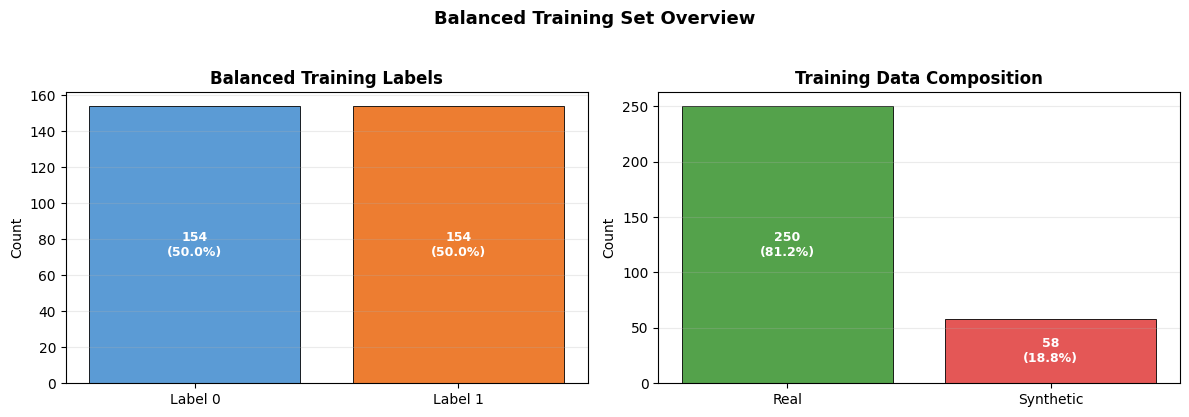

Balanced training set:
  Total      : 308
  Label = 0  : 154
  Label = 1  : 154
  Synthetic  : 58


,NC,DM,NS,ADD,SUB,CA,Label,NC_incomplete,DM_incomplete,NS_incomplete,...,SUB_incomplete,CA_incomplete,any_incomplete,NP,SN,AF,BC,AS,PF,is_synthetic
0,821.736842,2534.250000,6.0,29.0,26.0,14.5,1,0,0,0,...,1,1,1,1677.993421,-1712.513158,18.875,13.0,3.0,0.011249,0
1,1503.741422,2945.500000,11.0,32.0,36.0,17.0,0,0,0,0,...,0,0,0,2224.620711,-1441.758578,24.000,17.0,-4.0,0.010788,0
2,1195.480000,1855.170732,11.0,30.0,24.0,24.0,0,0,0,0,...,0,1,1,1525.325366,-659.690732,22.250,3.0,6.0,0.014587,0
3,859.591837,1832.775000,17.0,32.0,35.0,24.0,0,0,0,0,...,0,0,0,1346.183418,-973.183163,27.000,9.5,-3.0,0.020057,0
4,1229.583333,2728.342105,15.0,43.0,31.0,20.0,0,0,0,0,...,0,0,0,1978.962719,-1498.758772,27.250,17.0,12.0,0.013770,0


In [24]:
df_train_full = compute_derived(df_train)
df_train_full['is_synthetic'] = 0

# Concatenate real and synthetic training rows into one balanced training set.
df_train_balanced = pd.concat([df_train_full, df_selected_full], ignore_index=True)
counts = df_train_balanced['Label'].value_counts().sort_index()
source_counts = df_train_balanced['is_synthetic'].value_counts().sort_index()
total_rows = len(df_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance (0 vs 1)
label_vals = [counts.get(0, 0), counts.get(1, 0)]
label_bars = axes[0].bar(['Label 0', 'Label 1'], label_vals,
                         color=[TYPICAL_COLOR, AT_RIST_COLOR], edgecolor='black', linewidth=0.6)
axes[0].set_title('Balanced Training Labels', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.25)

# Real vs Synthetic composition
source_vals = [source_counts.get(0, 0), source_counts.get(1, 0)]
source_bars = axes[1].bar(['Real', 'Synthetic'], source_vals,
                          color=[REAL_COLOR, SYNTHETIC_COLOR], edgecolor='black', linewidth=0.6)
axes[1].set_title('Training Data Composition', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.25)

# Annotate bars with count + percentage in the middle
for ax, values, bars in [
    (axes[0], label_vals, label_bars),
    (axes[1], source_vals, source_bars),
]:
    for value, bar in zip(values, bars):
        pct = (value / total_rows * 100) if total_rows else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{value}\n({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='white',
        )

plt.suptitle('Balanced Training Set Overview', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Balanced training set:')
print(f'  Total      : {len(df_train_balanced)}')
print(f'  Label = 0  : {counts.get(0, 0)}')
print(f'  Label = 1  : {counts.get(1, 0)}')
print(f'  Synthetic  : {source_counts.get(1, 0)}')

display(df_train_balanced.head())

## 7. Visualisations

Four visual assessments:
1. **Overlaid histograms** — marginal distribution match per raw feature
2. **Q-Q plots** — quantile-level alignment per raw feature
3. **Correlation heatmaps** — feature relationship preservation
4. **Distribution check summary heatmap** — all metrics at a glance


### 7.1 Overlaid Histograms

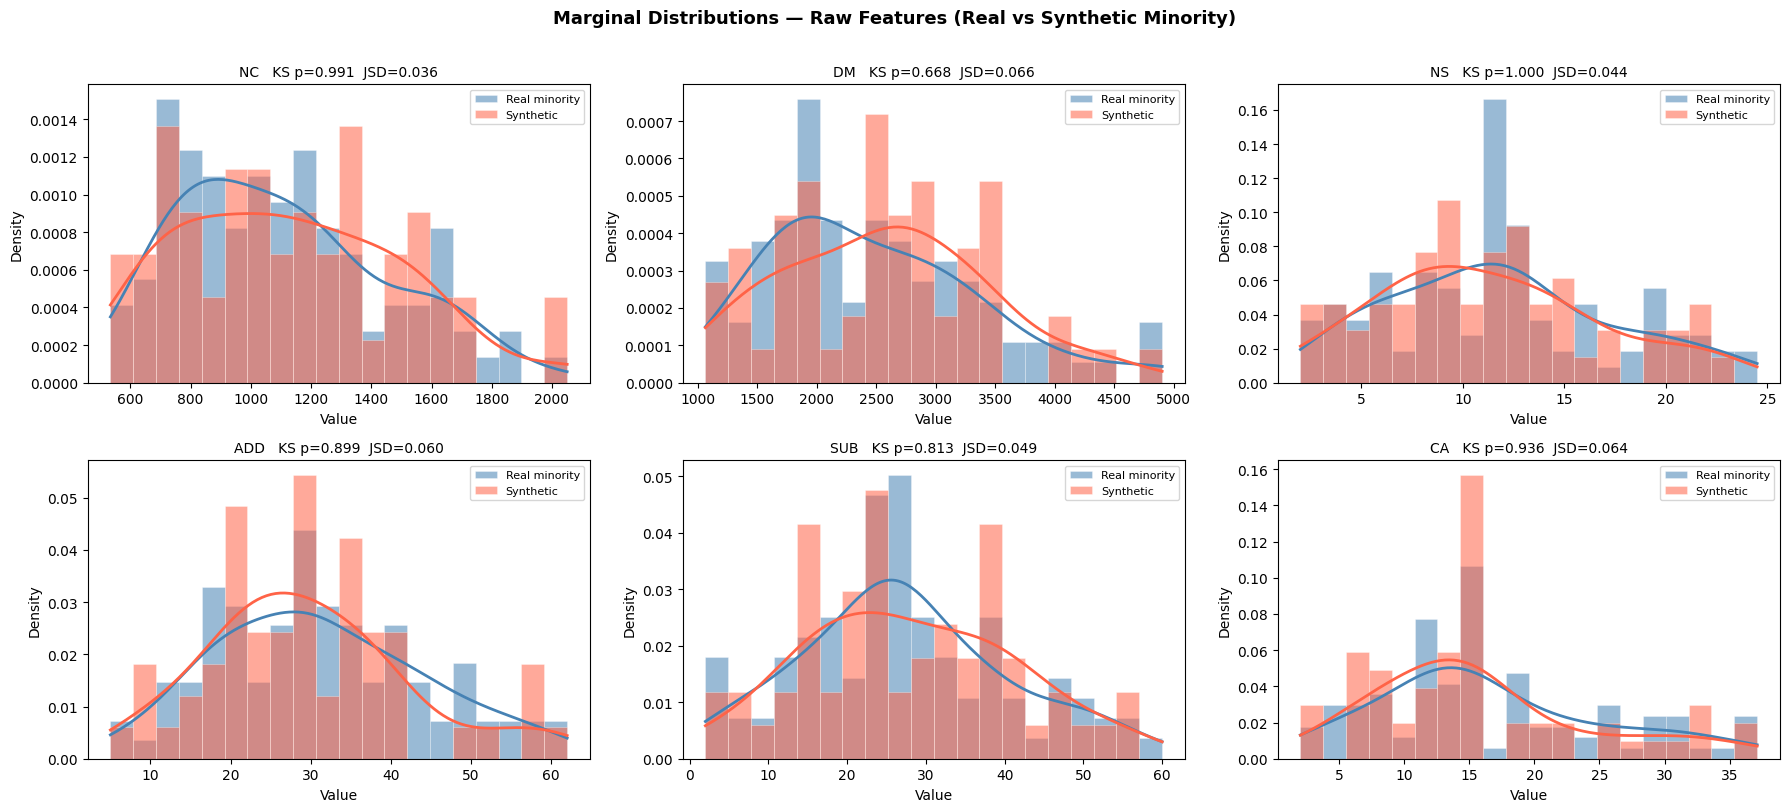

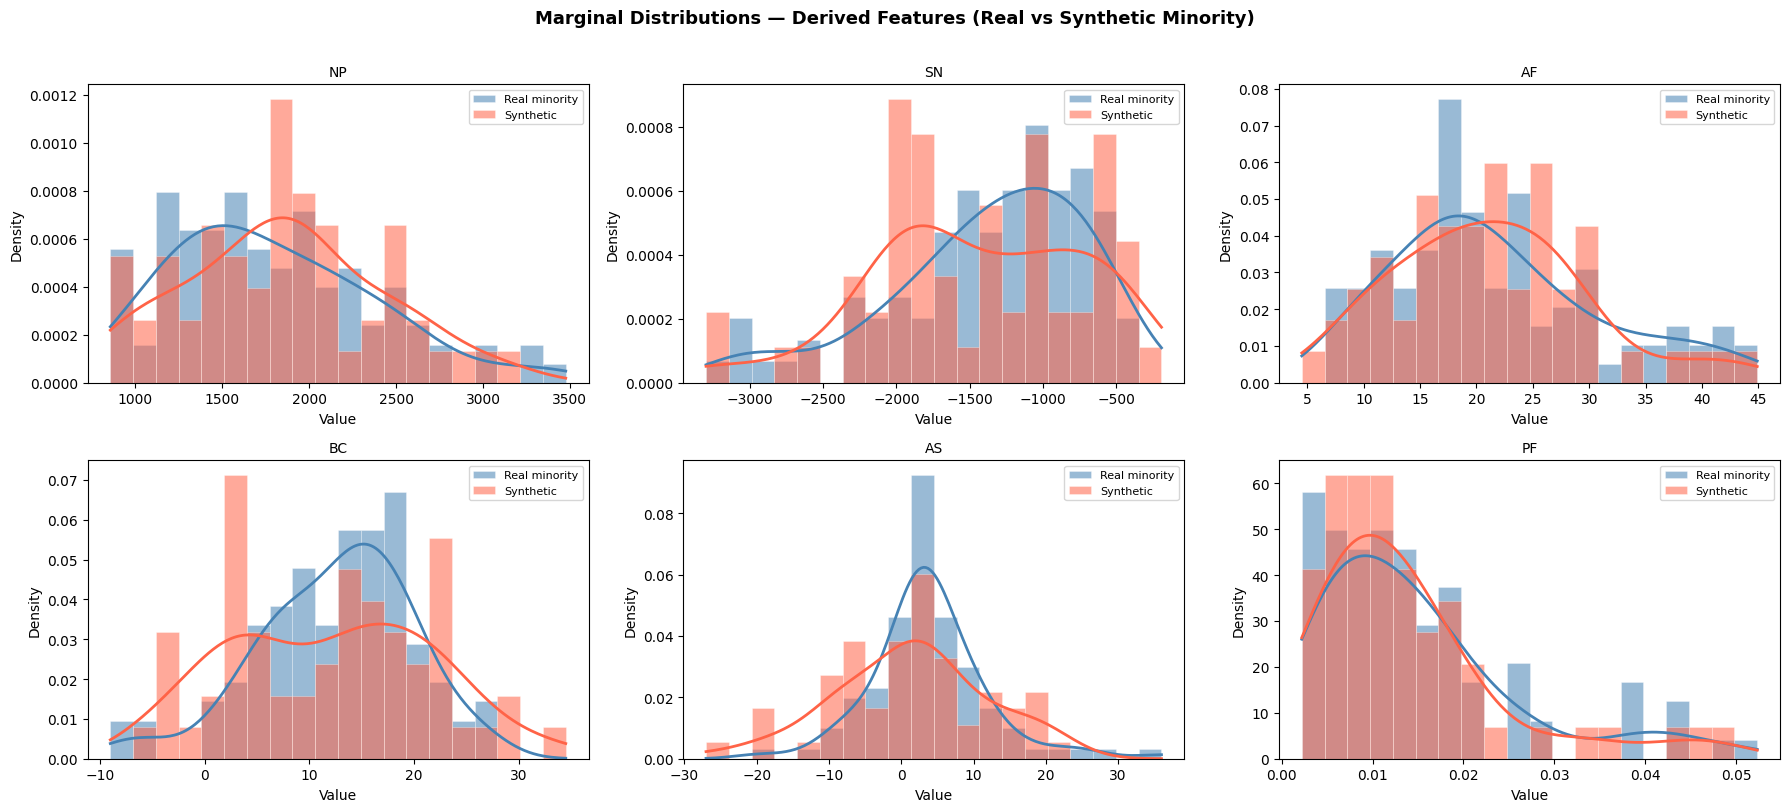

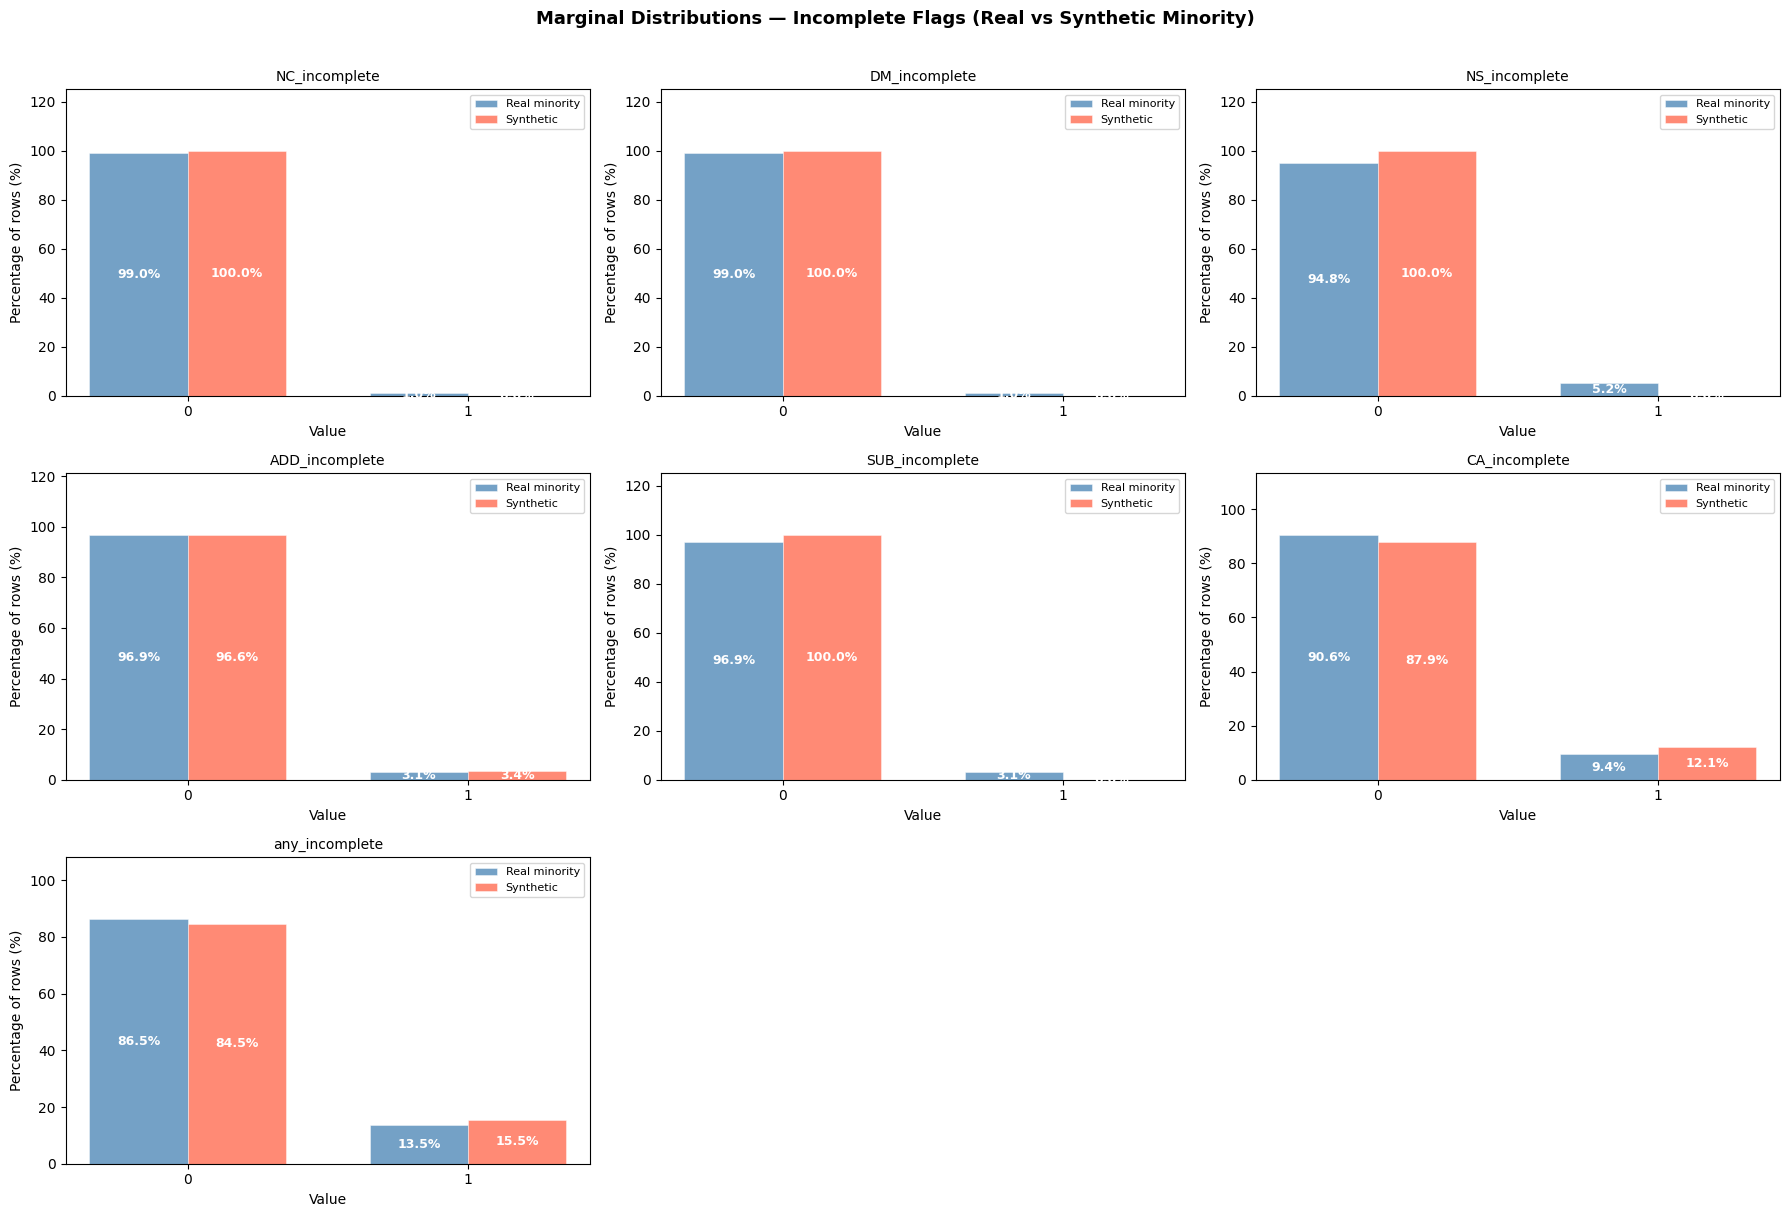

In [25]:
FEATURE_GROUPS = {
    'Raw Features': RAW_FEATURES,
    'Derived Features': ['NP', 'SN', 'AF', 'BC', 'AS', 'PF'],
    'Incomplete Flags': [f + '_incomplete' for f in RAW_FEATURES] + ['any_incomplete'],
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_vals = df_train_vis[f]
        syn_vals  = df_selected_full[f]

        if f.endswith('_incomplete') or f == 'any_incomplete':
            categories = np.array([0, 1])
            real_pct = [((real_vals == value).mean() * 100) for value in categories]
            syn_pct  = [((syn_vals == value).mean() * 100) for value in categories]
            x = np.arange(len(categories))
            width = 0.35

            real_bars = ax.bar(x - width / 2, real_pct, width,
                               color='steelblue', alpha=0.75,
                               label='Real minority', edgecolor='white', linewidth=0.4)
            syn_bars = ax.bar(x + width / 2, syn_pct, width,
                              color='tomato', alpha=0.75,
                              label='Synthetic', edgecolor='white', linewidth=0.4)

            ax.set_xticks(x)
            ax.set_xticklabels(['0', '1'])
            ax.set_ylabel('Percentage of rows (%)')
            ax.set_ylim(0, max(real_pct + syn_pct) * 1.25 if (real_pct + syn_pct) else 1)

            for bars in (real_bars, syn_bars):
                for bar in bars:
                    h = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                            f'{h:.1f}%', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
        else:
            bins = np.histogram_bin_edges(np.concatenate([real_vals, syn_vals]), bins=20)

            ax.hist(real_vals, bins=bins, alpha=0.55, color='steelblue',
                    label='Real minority', density=True, edgecolor='white', linewidth=0.4)
            ax.hist(syn_vals,  bins=bins, alpha=0.55, color='tomato',
                    label='Synthetic',    density=True, edgecolor='white', linewidth=0.4)

            # KDE curves for non-degenerate distributions
            from scipy.stats import gaussian_kde
            if len(np.unique(real_vals)) > 1 and len(np.unique(syn_vals)) > 1:
                xgrid = np.linspace(bins[0], bins[-1], 200)
                ax.plot(xgrid, gaussian_kde(real_vals)(xgrid), color='steelblue', lw=2)
                ax.plot(xgrid, gaussian_kde(syn_vals)(xgrid),  color='tomato',    lw=2)

            ax.set_ylabel('Density')

        # Keep KS/JSD annotation only for raw features
        if df_dist_results is not None and f in RAW_FEATURES:
            row = df_dist_results[df_dist_results['feature'] == f].iloc[0]
            ax.set_title(f"{f}   KS p={row['KS_p']:.3f}  JSD={row['JSD']:.3f}", fontsize=10)
        else:
            ax.set_title(f, fontsize=10)

        ax.set_xlabel('Value')
        ax.legend(fontsize=8)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Marginal Distributions — {group_name} (Real vs Synthetic Minority)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 7.2 Q-Q Plots

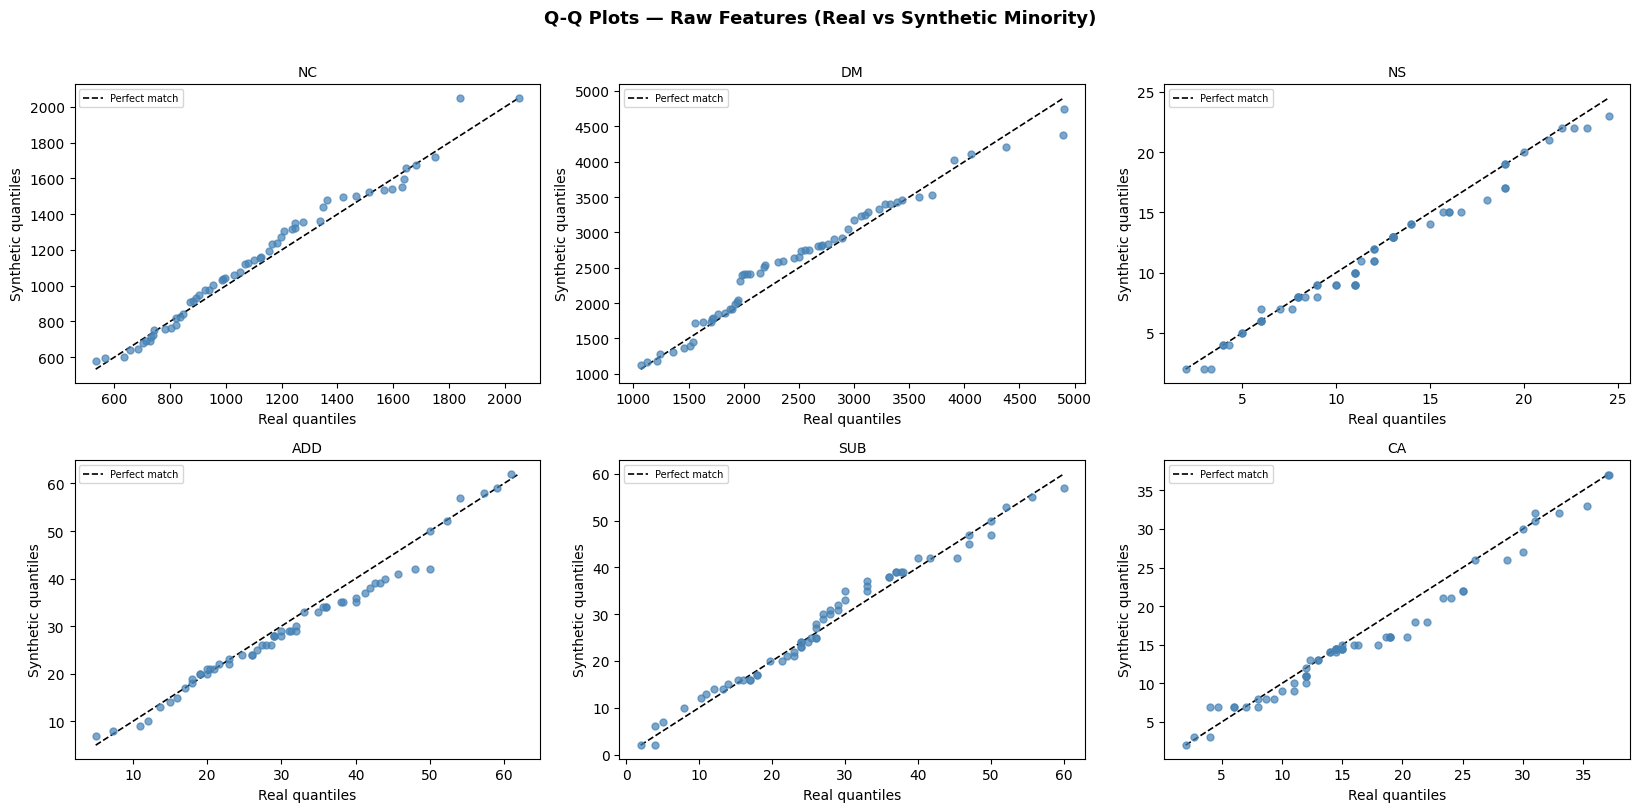

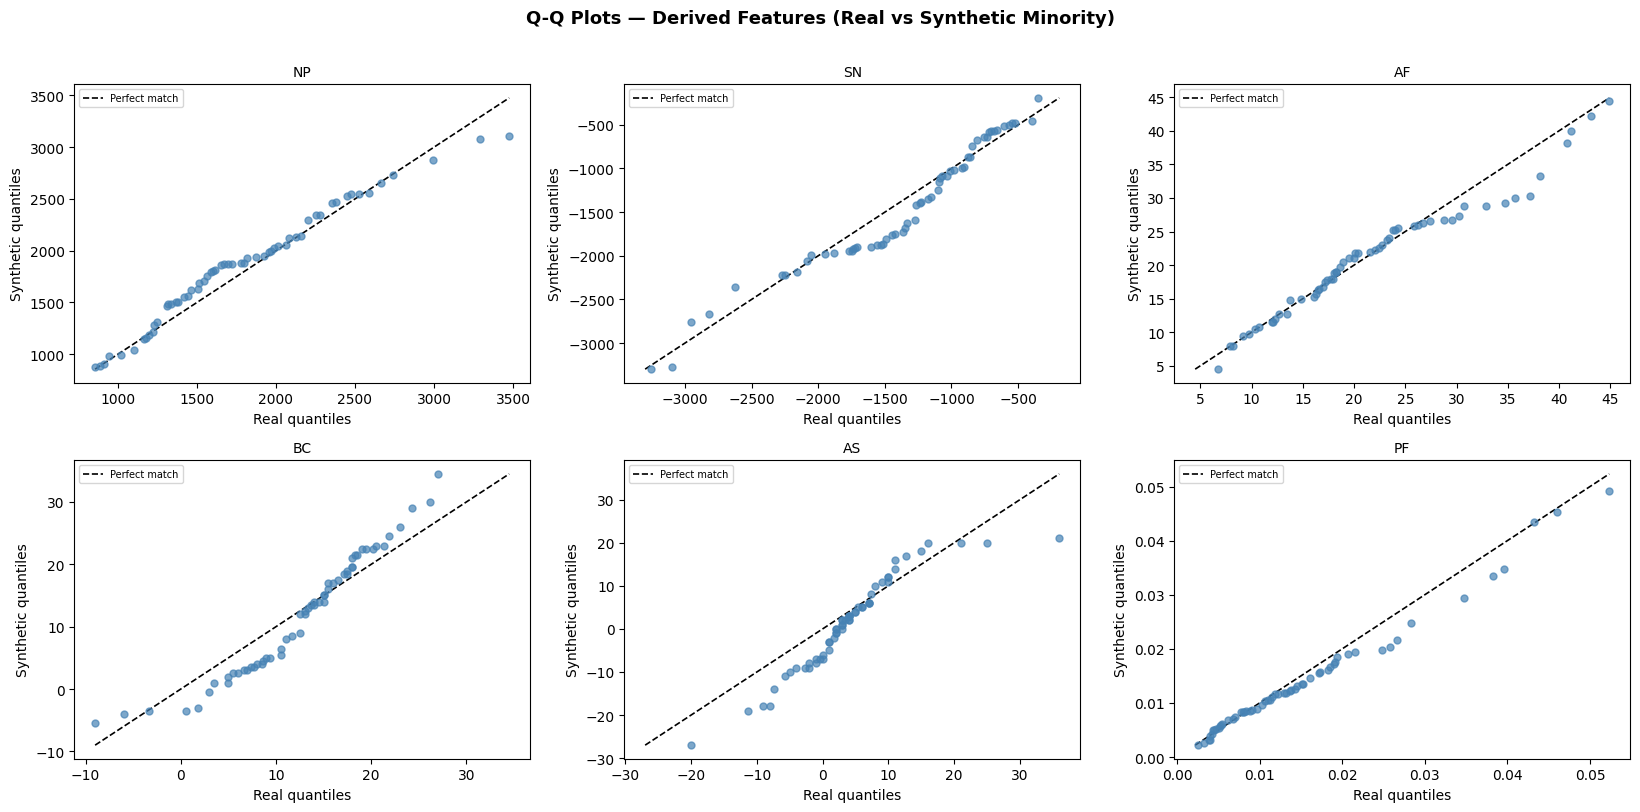

In [27]:
FEATURE_GROUPS = {
    'Raw Features': RAW_FEATURES,
    'Derived Features': ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_sorted = np.sort(df_train_vis[f].values)
        syn_sorted  = np.sort(df_selected_full[f].values)

        # Interpolate to common quantile grid
        quantiles = np.linspace(0, 1, min(len(real_sorted), len(syn_sorted)))
        real_q = np.quantile(real_sorted, quantiles)
        syn_q  = np.quantile(syn_sorted,  quantiles)

        ax.scatter(real_q, syn_q, color='steelblue', alpha=0.7, s=25, zorder=3)

        # Perfect-match reference line
        lo = min(real_q.min(), syn_q.min())
        hi = max(real_q.max(), syn_q.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect match')

        ax.set_title(f, fontsize=10)
        ax.set_xlabel('Real quantiles')
        ax.set_ylabel('Synthetic quantiles')
        ax.legend(fontsize=7)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Q-Q Plots — {group_name} (Real vs Synthetic Minority)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 7.3 Correlation Matrix Heatmaps

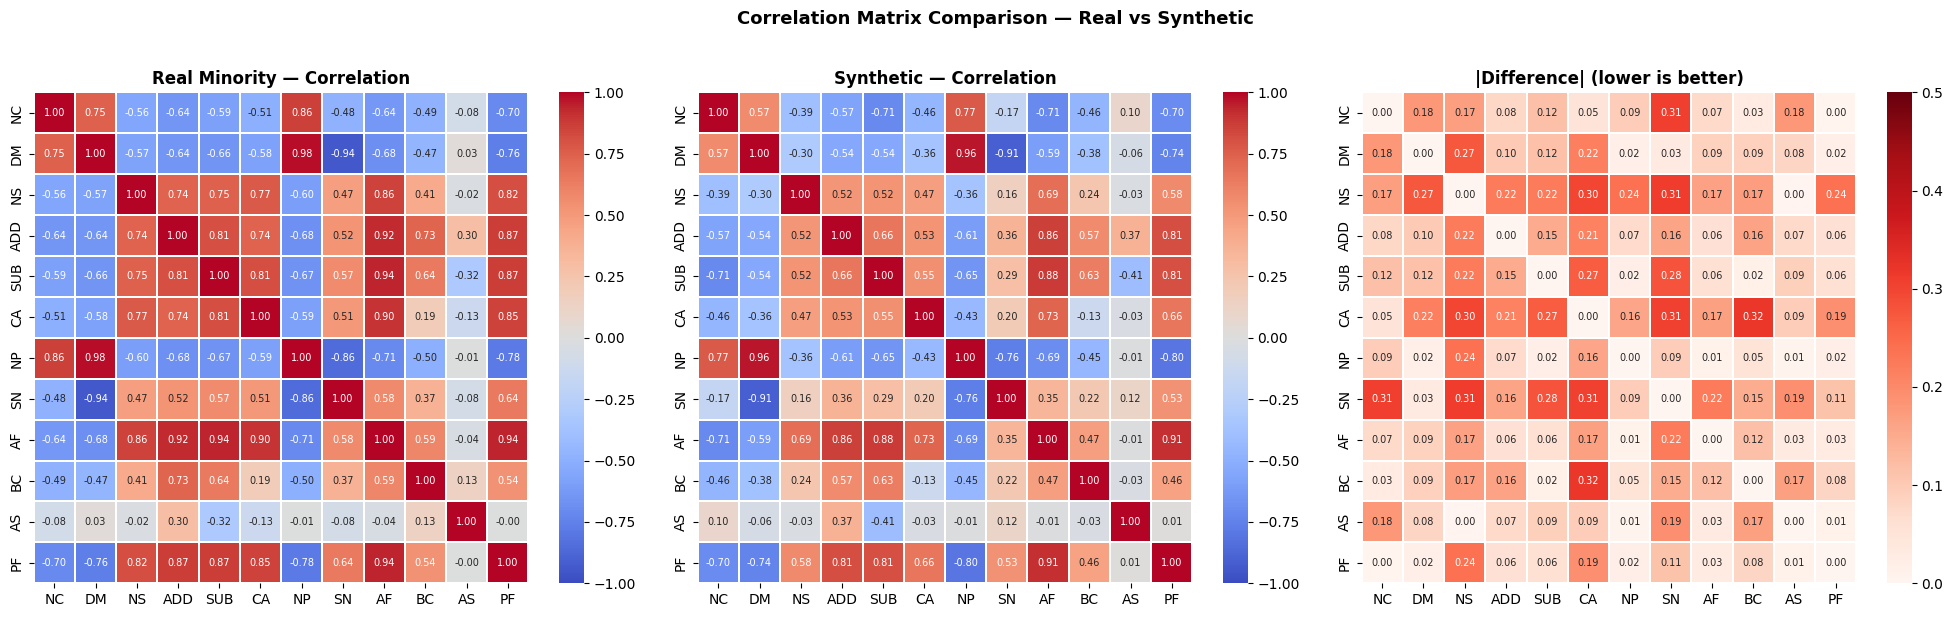

In [28]:
ALL_FEATURES = RAW_FEATURES + ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']

corr_real = df_train_full[df_train_full['Label'] == 1][ALL_FEATURES].corr()
corr_syn  = df_selected_full[ALL_FEATURES].corr()
corr_diff = (corr_syn - corr_real).abs()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kw = dict(annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
           linewidths=0.3, annot_kws={'size': 7})

sns.heatmap(corr_real, ax=axes[0], **kw)
axes[0].set_title('Real Minority — Correlation', fontweight='bold')

sns.heatmap(corr_syn, ax=axes[1], **kw)
axes[1].set_title('Synthetic — Correlation', fontweight='bold')

sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt='.2f',
            cmap='Reds', vmin=0, vmax=0.5,
            linewidths=0.3, annot_kws={'size': 7})
axes[2].set_title('|Difference| (lower is better)', fontweight='bold')

plt.suptitle('Correlation Matrix Comparison — Real vs Synthetic',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Distribution Check Summary

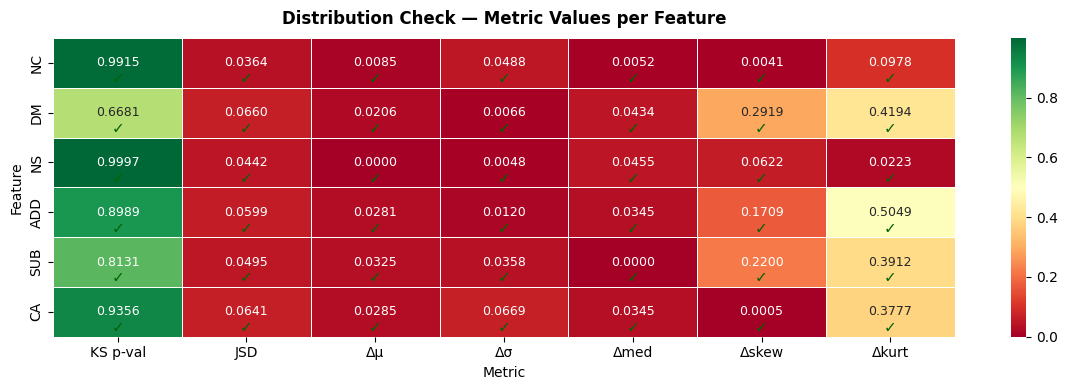

In [29]:
if df_dist_results is not None:
    metrics   = ['KS_p', 'JSD', 'delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt']
    thresholds = {
        'KS_p'      : (0.05,  True),   # (threshold, higher_is_better)
        'JSD'       : (DIST_THRESHOLDS['JSD_THRESHOLD'], False),
        'delta_mu'  : (DIST_THRESHOLDS['T_mu'],   False),
        'delta_std' : (DIST_THRESHOLDS['T_sigma'], False),
        'delta_med' : (DIST_THRESHOLDS['T_med'],   False),
        'delta_skew': (DIST_THRESHOLDS['T_skew'],  False),
        'delta_kurt': (DIST_THRESHOLDS['T_kurt'],  False),
    }
    labels = ['KS p-val', 'JSD', 'Δμ', 'Δσ', 'Δmed', 'Δskew', 'Δkurt']

    heat_val  = df_dist_results.set_index('feature')[metrics]

    # Build pass/fail mask
    pass_mask = pd.DataFrame(index=heat_val.index, columns=metrics)
    for m, (thr, higher) in thresholds.items():
        if higher:
            pass_mask[m] = heat_val[m] > thr
        else:
            pass_mask[m] = heat_val[m] < thr

    fig, ax = plt.subplots(figsize=(12, 4))
    heat_display = heat_val.copy()
    heat_display.columns = labels

    sns.heatmap(
        heat_display.astype(float),
        ax=ax, annot=True, fmt='.4f',
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )

    # Overlay ✓/✗ on each cell
    for row_i, feat in enumerate(heat_val.index):
        for col_j, m in enumerate(metrics):
            ok = pass_mask.loc[feat, m]
            ax.text(col_j + 0.5, row_i + 0.82, '✓' if ok else '✗',
                    ha='center', va='center', fontsize=11,
                    color='darkgreen' if ok else 'darkred', fontweight='bold')

    ax.set_title('Distribution Check — Metric Values per Feature',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Metric')
    ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

## 8. Save Outputs

In [31]:
df_val_full  = compute_derived(df_val)
df_test_full = compute_derived(df_test)

# Real Train Data only (both labels 0 and 1)
df_train_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_DIR / 'train.csv', index=False)

# Synthetic Train Data (label 1 only)
df_selected_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_DIR / 's_train.csv', index=False)

# Validation and Test Data
df_val_full.to_csv(DATASETS_DIR / 'val.csv',   index=False)
df_test_full.to_csv(DATASETS_DIR / 'test.csv', index=False)

print(f'Files saved to {DATASETS_DIR}:')
print(f'  train.csv    — {len(df_train_full)} rows (real only, labels 0 and 1)')
print(f'  s_train.csv  — {len(df_selected_full[df_selected_full["Label"] == 1])} rows (synthetic only, label 1)')
print(f'  val.csv      — {len(df_val_full)} rows (real only)')
print(f'  test.csv     — {len(df_test_full)} rows (real only)')


Files saved to ../datasets:
  train.csv    — 250 rows (real only, labels 0 and 1)
  s_train.csv  — 58 rows (synthetic only, label 1)
  val.csv      — 54 rows (real only)
  test.csv     — 54 rows (real only)
